# Method 3 Recovery And Single-Temperature `p_det` Review

Human-review notebook for Stages 06 and 07. It inspects the deterministic fake-curve walkthrough, recovery cutflow, one-temperature `p_det` grid, seed check, and existing diagnostic figures.

In [2]:
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_workspace():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'trap_completeness_method3').exists():
            return candidate
    raise RuntimeError('Could not find repo root containing trap_completeness_method3')

root = find_workspace()
workspace = root / 'trap_completeness_method3'
cache = workspace / 'cache'

plt.rcParams['figure.dpi'] = 120
root, cache

(WindowsPath('C:/Users/Ansh/Projects/sensei_charge_traps'),
 WindowsPath('C:/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/cache'))

## Stage 06 Single-Curve Recovery

In [3]:
with (cache / '06_single_curve_recovery_summary.json').open() as f:
    s06 = json.load(f)

case_rows = []
for case, stats in s06['case_summaries'].items():
    case_rows.append({
        'case': case,
        'pass_fraction': stats['pass_fraction'],
        'pass_count': stats['pass_count'],
        'realizations': stats['realizations'],
        'median_fit_tau_over_true': stats['fit_tau_over_true']['median'],
        'median_fit_tau_rel_err': stats['fit_tau_rel_err']['median'],
    })
case_df = pd.DataFrame(case_rows)
display(case_df)

,case,pass_fraction,pass_count,realizations,median_fit_tau_over_true,median_fit_tau_rel_err
0,effectively_undetectable_long,0.000000,0,128,0.005545,2.037607
1,long_reachable_peak,0.953125,122,128,1.024372,0.176450
2,long_rising_edge,0.054688,7,128,1.323551,1.808266
3,near_peak_reachable,0.968750,124,128,1.019900,0.106734
4,short_outside_band,0.007812,1,128,142.688725,1.584757


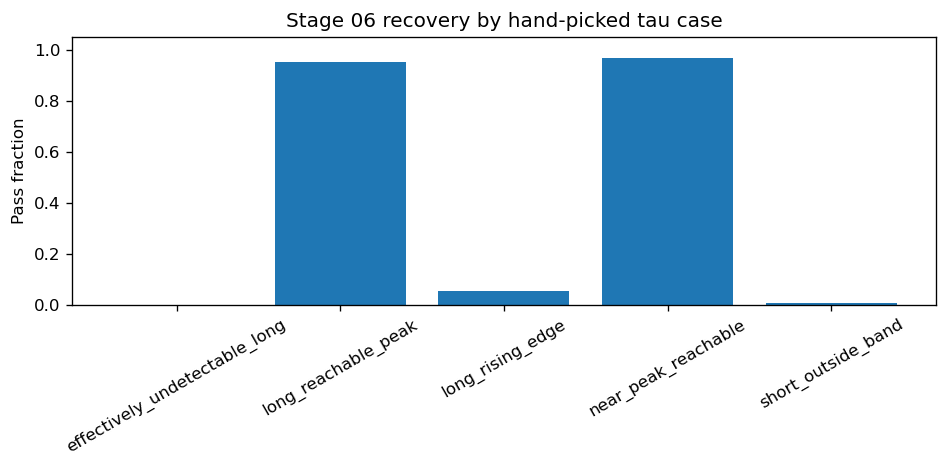

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(case_df['case'], case_df['pass_fraction'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Pass fraction')
ax.set_title('Stage 06 recovery by hand-picked tau case')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()

In [5]:
recovery_rows = pd.read_csv(cache / '06_single_curve_recovery.csv')
display(recovery_rows.head())

cut_counts = recovery_rows.groupby(['tau_case', 'controlling_failure_cut']).size().unstack(fill_value=0)
display(cut_counts)

,producing_stage,produced_at,random_seed,temperature_K,quadrant,tau_case,realization,true_tau_seconds,true_amplitude_electrons,true_fit_coeff,...,fit_tau_err_seconds,fit_tau_rel_err,fit_p_value,fit_chi_squared,fit_reduced_chi_squared,fit_r_squared,fit_lin_r_squared,fit_const_lin_r_squared,controlling_failure_cut,failed_cuts
0,06_single_curve_recovery,2026-05-20T14:04:14-07:00,2026052006,160,0,short_outside_band,0,0.00002,3168.45408,1.056151,...,0.000069,1.363169,0.385195,17.006221,1.062889,0.156107,0.000122,-0.002003,max_intensity_lt_3_mean_intensity_err,max_intensity_lt_3_mean_intensity_err;max_inte...
1,06_single_curve_recovery,2026-05-20T14:04:14-07:00,2026052006,160,0,short_outside_band,1,0.00002,3168.45408,1.056151,...,0.001488,2.904555,0.837943,10.522748,0.657672,0.039594,0.024521,-0.001033,max_intensity_lt_3_mean_intensity_err,max_intensity_lt_3_mean_intensity_err;max_inte...
2,06_single_curve_recovery,2026-05-20T14:04:14-07:00,2026052006,160,0,short_outside_band,2,0.00002,3168.45408,1.056151,...,0.379486,10.353914,0.076010,24.661967,1.541373,-0.003514,0.070038,-0.000120,max_intensity_lt_3_mean_intensity_err,max_intensity_lt_3_mean_intensity_err;max_inte...
3,06_single_curve_recovery,2026-05-20T14:04:14-07:00,2026052006,160,0,short_outside_band,3,0.00002,3168.45408,1.056151,...,0.008508,1.334551,0.125032,22.593805,1.412113,0.069848,0.011669,-0.005079,max_intensity_lt_3_mean_intensity_err,max_intensity_lt_3_mean_intensity_err;max_inte...
4,06_single_curve_recovery,2026-05-20T14:04:14-07:00,2026052006,160,0,short_outside_band,4,0.00002,3168.45408,1.056151,...,0.000053,0.557771,0.852228,10.268641,0.641790,0.574345,0.128018,-0.000474,max_intensity_lt_3_mean_intensity_err,max_intensity_lt_3_mean_intensity_err;max_inte...


controlling_failure_cut,max_intensity_lt_3_image_sigma,max_intensity_lt_3_mean_intensity_err,p_value,pass,tau_relative_error_gt_0p5
tau_case,,,,,
effectively_undetectable_long,4,117,6,0,1
long_reachable_peak,0,0,6,122,0
long_rising_edge,2,2,8,7,109
near_peak_reachable,0,0,4,124,0
short_outside_band,4,111,8,1,4


## Stage 07 Single-Temperature `p_det`

In [6]:
with (cache / '07_single_temperature_pdet_summary.json').open() as f:
    s07 = json.load(f)

pd.Series({
    'temperature_K': s07['temperature_K'],
    'quadrant': s07['quadrant'],
    'grid_points': s07['shape']['grid_points'],
    'fits_main_grid': s07['shape']['fits_main_grid'],
    'realizations_per_grid_point': s07['realizations_per_grid_point'],
    'p_det_mean': s07['p_det_summary']['mean'],
    'p_det_median': s07['p_det_summary']['median'],
    'bright_reachable_median': s07['bright_reachable_p_det']['median'],
    'unreachable_low_amplitude_max': s07['unreachable_low_amplitude_p_det']['max'],
    'alternate_seed_max_delta': s07['alternate_seed_subset']['absolute_delta_summary']['max'],
})

temperature_K                      160.000000
quadrant                             0.000000
grid_points                        210.000000
fits_main_grid                   16800.000000
realizations_per_grid_point         80.000000
p_det_mean                           0.427143
p_det_median                         0.206250
bright_reachable_median              0.950000
unreachable_low_amplitude_max        0.012500
alternate_seed_max_delta             0.025000
dtype: float64

In [7]:
pd.Series(s07['dominant_controlling_cut_fractions']).sort_values(ascending=False)

pass                                     0.427143
max_intensity_lt_3_mean_intensity_err    0.401726
tau_relative_error_gt_0p5                0.070774
max_intensity_lt_3_image_sigma           0.050417
p_value                                  0.049940
fit_failed                               0.000000
dtype: float64

In [8]:
pdet_h5 = cache / '07_single_temperature_pdet_160K_v1.h5'
with h5py.File(pdet_h5, 'r') as h5:
    print('Top-level keys:', list(h5.keys()))
    for key in h5.keys():
        obj = h5[key]
        if isinstance(obj, h5py.Dataset):
            print(key, obj.shape, obj.dtype)
        else:
            print(key, 'group')

Top-level keys: ['alternate_seed_subset', 'grid', 'results']
alternate_seed_subset group
grid group
results group


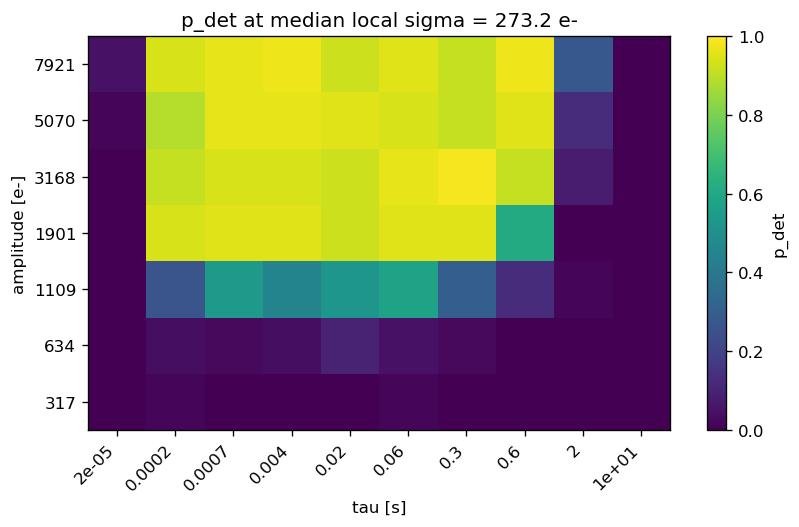

In [9]:
with h5py.File(pdet_h5, 'r') as h5:
    p_det = h5['results/p_det'][...]
    tau = h5['grid/tau_seconds'][...]
    amp = h5['grid/amplitude_electrons'][...]
    sigmas = h5['grid/local_sigma_electrons'][...]

median_sigma_index = len(sigmas) // 2
grid = p_det[:, :, median_sigma_index]

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(grid.T, origin='lower', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(tau)))
ax.set_xticklabels([f'{x:.1g}' for x in tau], rotation=45, ha='right')
ax.set_yticks(np.arange(len(amp)))
ax.set_yticklabels([f'{x:.0f}' for x in amp])
ax.set_xlabel('tau [s]')
ax.set_ylabel('amplitude [e-]')
ax.set_title(f'p_det at median local sigma = {sigmas[median_sigma_index]:.1f} e-')
fig.colorbar(im, ax=ax, label='p_det')
fig.tight_layout()

## Existing Stage 06/07 Figures

C:\Users\Ansh\Projects\sensei_charge_traps\trap_completeness_method3\cache\figures\06_single_curve_recovery_examples.png


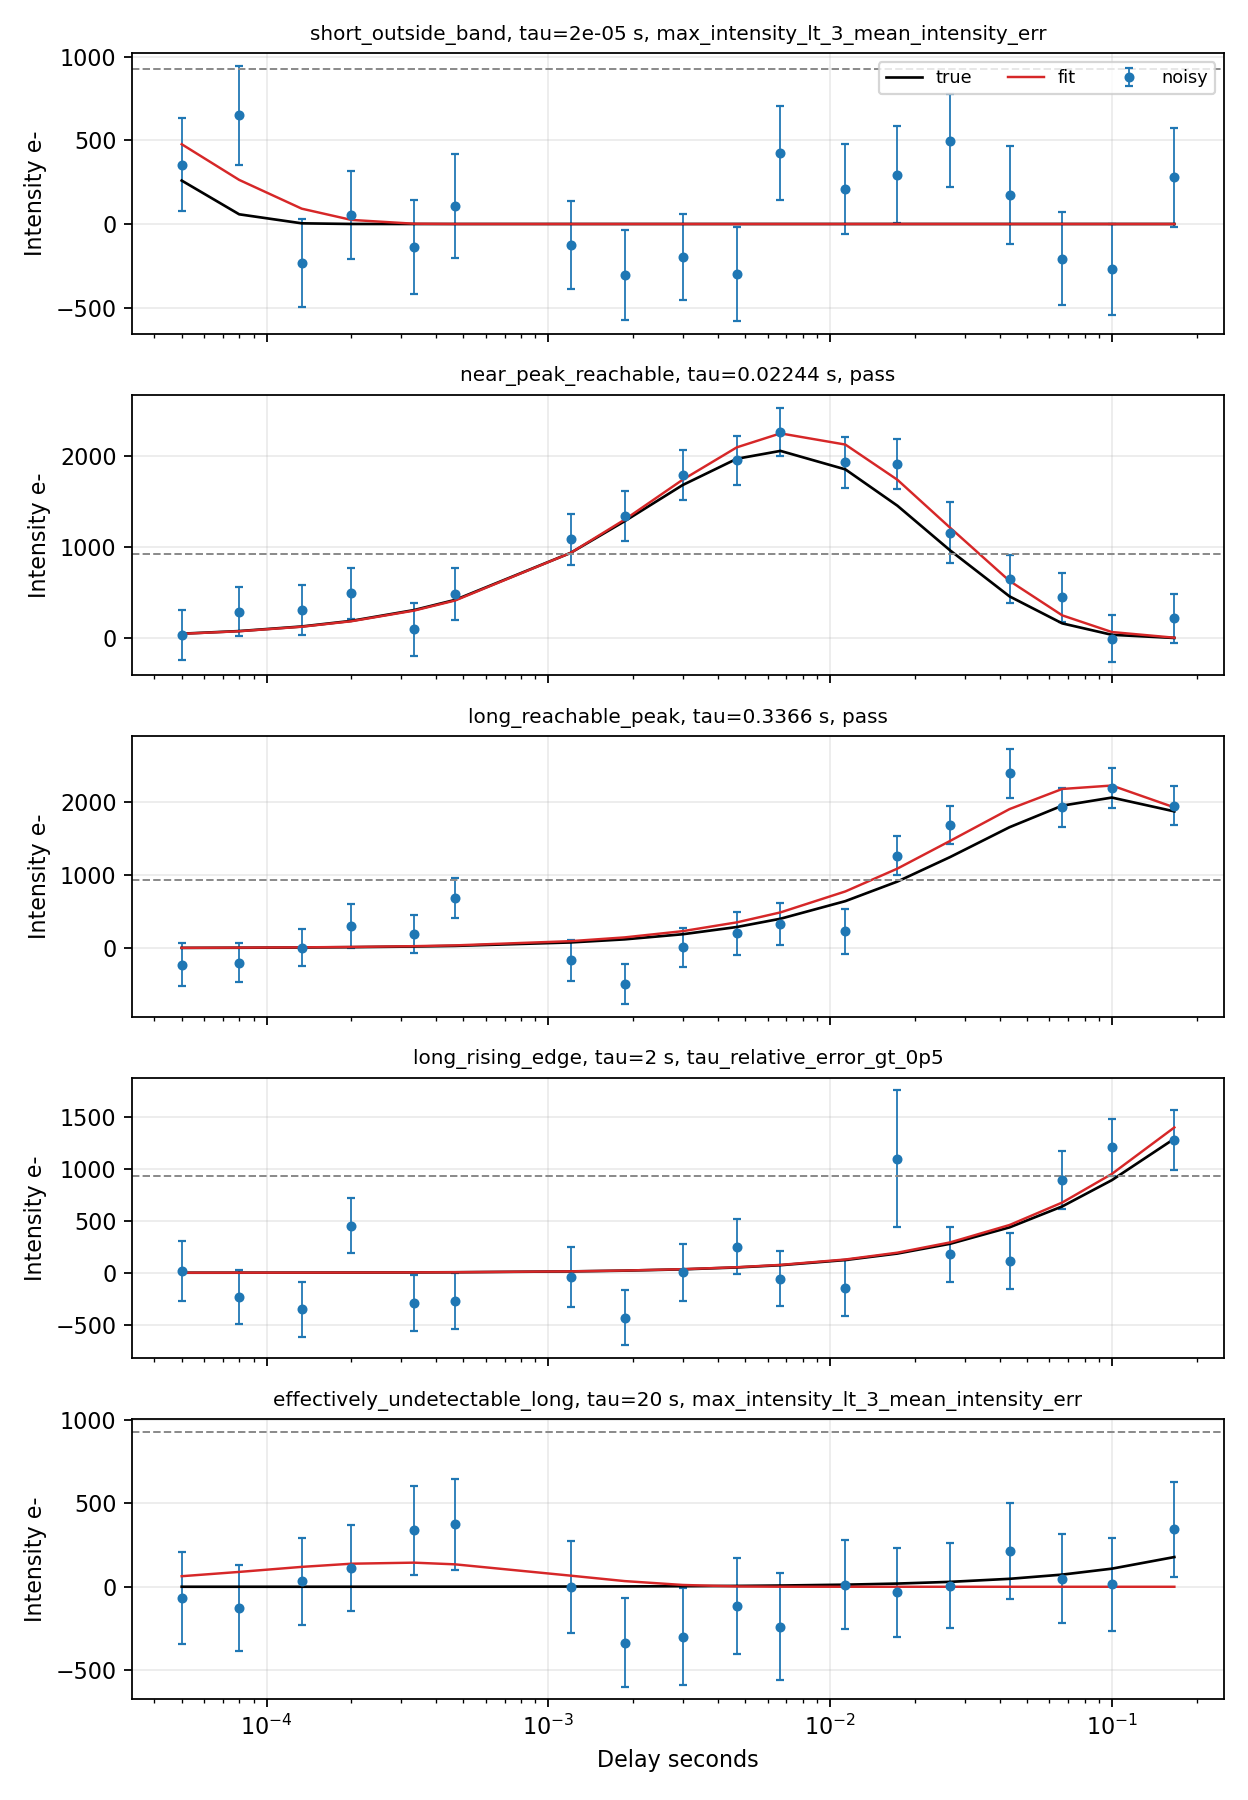

C:\Users\Ansh\Projects\sensei_charge_traps\trap_completeness_method3\cache\figures\07_single_temperature_pdet_160K_v1.png


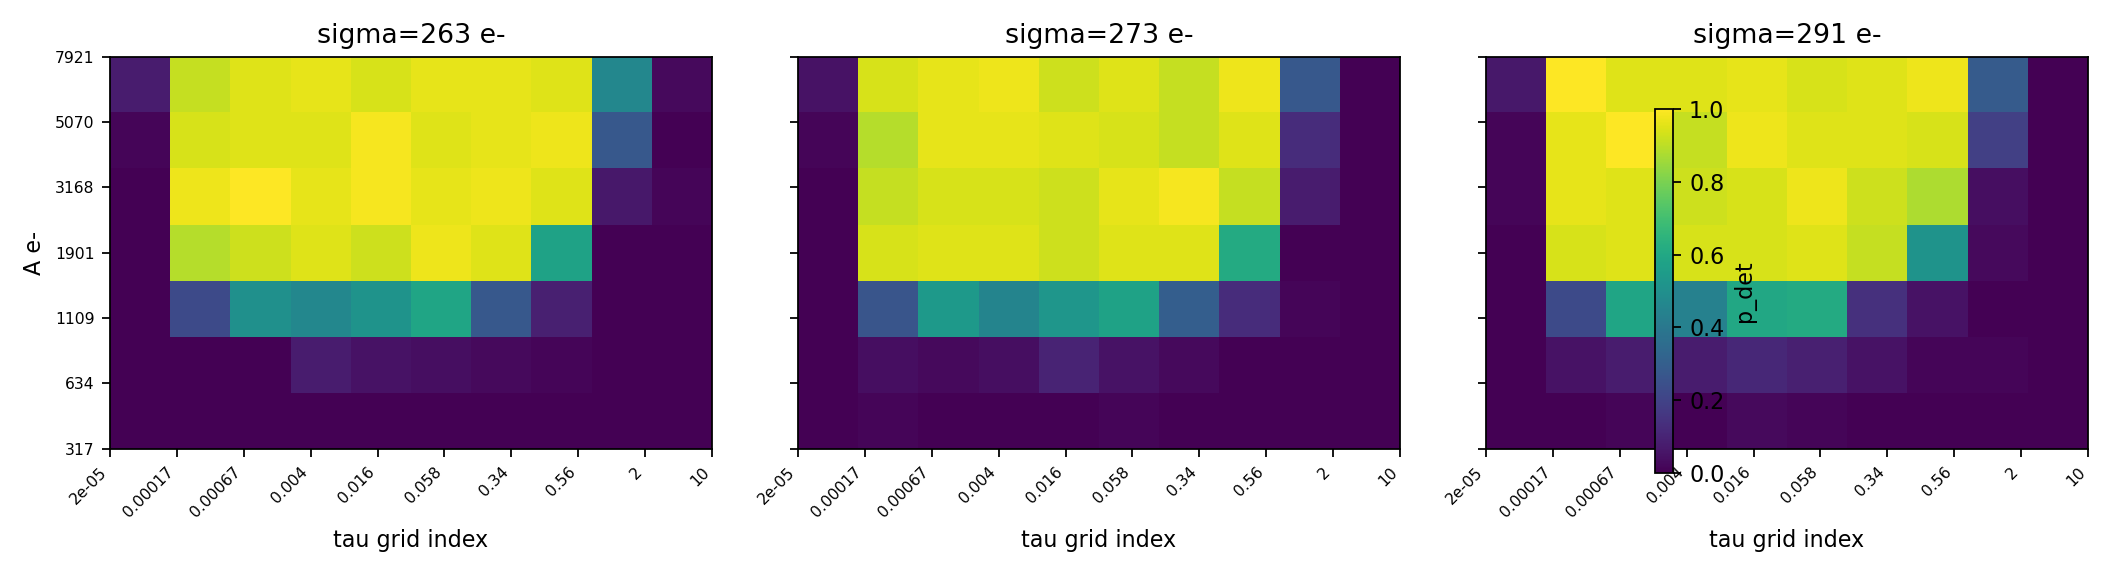

In [10]:
from IPython.display import Image, display

for name in ['06_single_curve_recovery_examples.png', '07_single_temperature_pdet_160K_v1.png']:
    path = cache / 'figures' / name
    if path.exists():
        print(path)
        display(Image(filename=str(path)))